In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

In [2]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

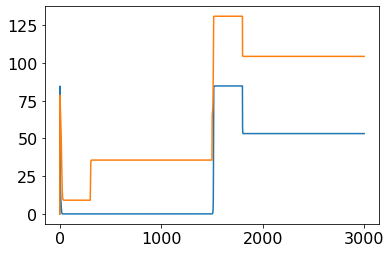

[[9.9409e-03 3.5642e+01]
 [5.3253e+01 1.0443e+02]]


In [3]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

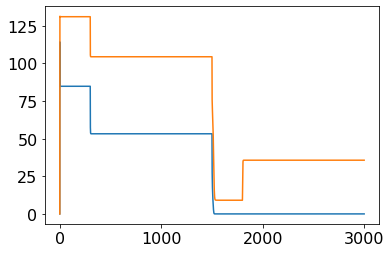

In [4]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2] * 0.99  

In [5]:
max_it = 5
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [6]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

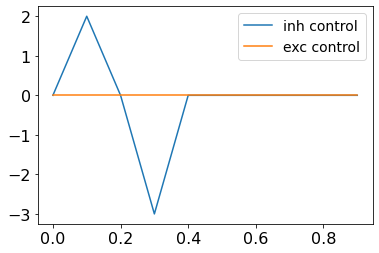

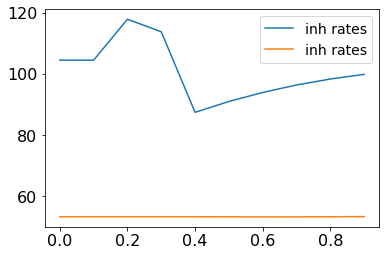

In [8]:
dur = .9
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

setinitvars(high_state_vars)

control0 = aln.getZeroControl()

control0[:,1,1] += 2.
control0[:,1,3] -= 3.

aln.run(control = control0)


plt.plot(aln.t, control0[0,1,:], label="inh control")
plt.plot(aln.t, control0[0,0,:], label="exc control")
plt.legend()
plt.show()

plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.plot(aln.t, aln.rates_exc[0,:], label="inh rates")
plt.legend()
plt.show()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

In [10]:
cost.setParams(1.0, 0., 1.0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 100
start_step = 10.
alg = "A1"
case = "deley_example"

aln.params.duration = dur
control0 = aln.getZeroControl()
#control1 = bestControlA[:,:,5:15]
#control1[0,:,:9] = bestControlA2[:,:,5:14]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = "HZ")#, variables_ = [0])

set cost params
RUN  0 , total integrated cost =  48.75243525172462
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
too large start step, decrease to  0.078125
RUN  1 , total integrated cost =  22.94511296043201
RUN  2 , total integrated cost =  3.0003698134911865
RUN  3 , total integrated cost =  2.2521496810448953
RUN  4 , total integrated cost =  1.499378085084846
RUN  5 , total integrated cost =  1.324405043323213
RUN  6 , total integrated cost =  1.2422113802419592
RUN  7 , total integrated cost =  1.2012173935534842
RUN  8 , total integrated cost =  1.1437280578969968
RUN  9 , total integrated cost =  1.1405546756767553
RUN  10 , total integrated cost =  1.1327264318363153
RUN  11 , total integrated cost =  1.131438687507371
RUN  12 , total integrated cost =  1.1304481670315312
RUN  13 , total integrated cost =  1.1302343037582567
RUN  14 , total integrated cost =  1.1299563754661281
RUN  15 , total integrated cost =  1.1298323774453627
RUN

ERROR:root:Problem in initial value trasfer


too large start step, decrease to  0.078125
RUN  72 , total integrated cost =  1.129699740122482
RUN  73 , total integrated cost =  1.129699740122482
Control only changes marginally.
Improved over  73  iterations by  97.68278295373456  percent.
Problem in initial value trasfer:  Vmean_exc -56.70429230464965 -56.70431096461321


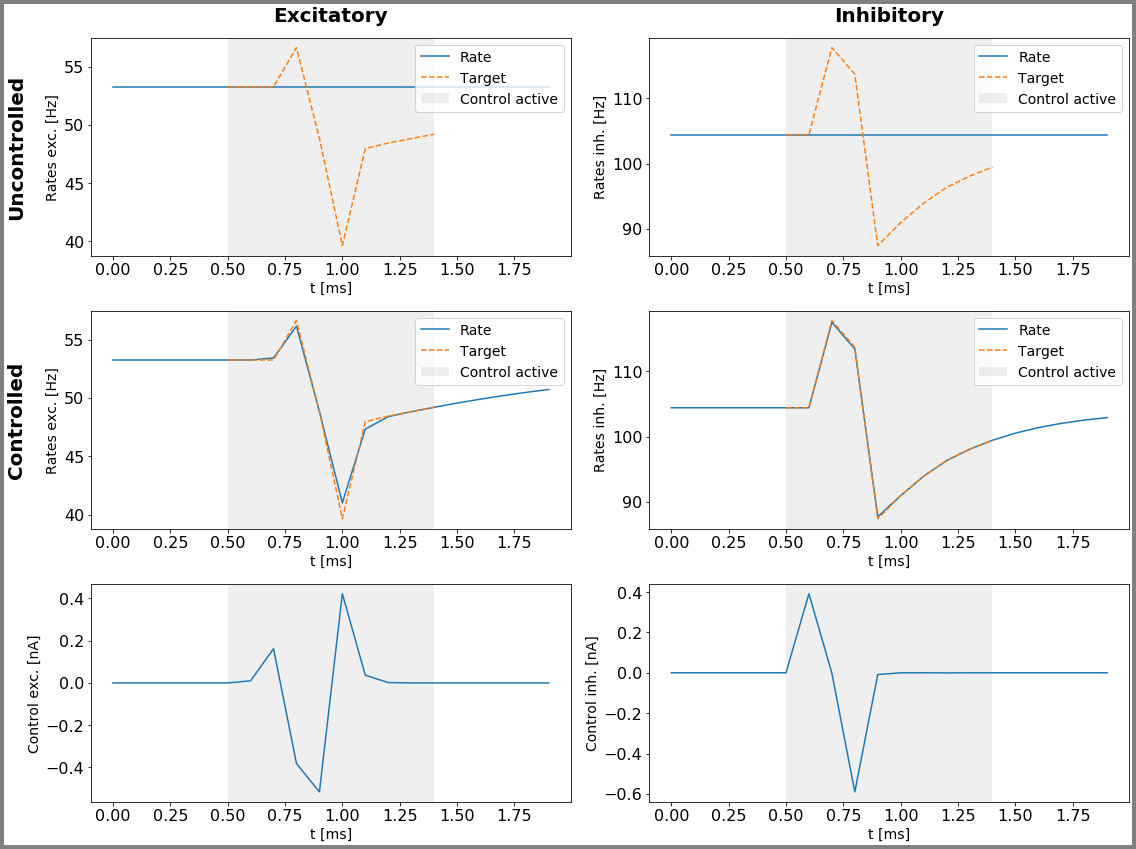

In [114]:
# None: 2.501835818420952
# HS: 2.4998774111347344
# FR: 2.499866173146085
# PR: 2.5018341942132687
# HZ: 2.4999280107904958

# A2: 2.4998777421894407

plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target, path)

RUN  0 , total integrated cost:  2.499878538084884
RUN  1 , total integrated cost:  2.4998785355199944
RUN  2 , total integrated cost:  2.4998785298766175
RUN  3 , total integrated cost:  2.499878524747298
RUN  4 , total integrated cost:  2.499878519618954
RUN  5 , total integrated cost:  2.499878514491586
RUN  6 , total integrated cost:  2.499878509365325
RUN  7 , total integrated cost:  2.4998785042398985
RUN  8 , total integrated cost:  2.4998784991154483
RUN  9 , total integrated cost:  2.4998784939921026
RUN  10 , total integrated cost:  2.4998784888697294
RUN  11 , total integrated cost:  2.4998784837481915
RUN  12 , total integrated cost:  2.499878478627763
RUN  13 , total integrated cost:  2.4998784735081734
RUN  14 , total integrated cost:  2.4998784683896886
RUN  15 , total integrated cost:  2.4998784632721724
RUN  16 , total integrated cost:  2.499878458155498
RUN  17 , total integrated cost:  2.499878453040123
RUN  18 , total integrated cost:  2.49987844945871
RUN  19 , tot

ERROR:root:Problem in initial value trasfer


RUN  123 , total integrated cost:  2.4998777421894407
Control only changes marginally.
RUN  124 , total integrated cost:  2.4998777421894407
Improved over  124  iterations by  1  percent.
Problem in initial value trasfer:  Vmean_exc -56.70178489064666 -56.70214184276665


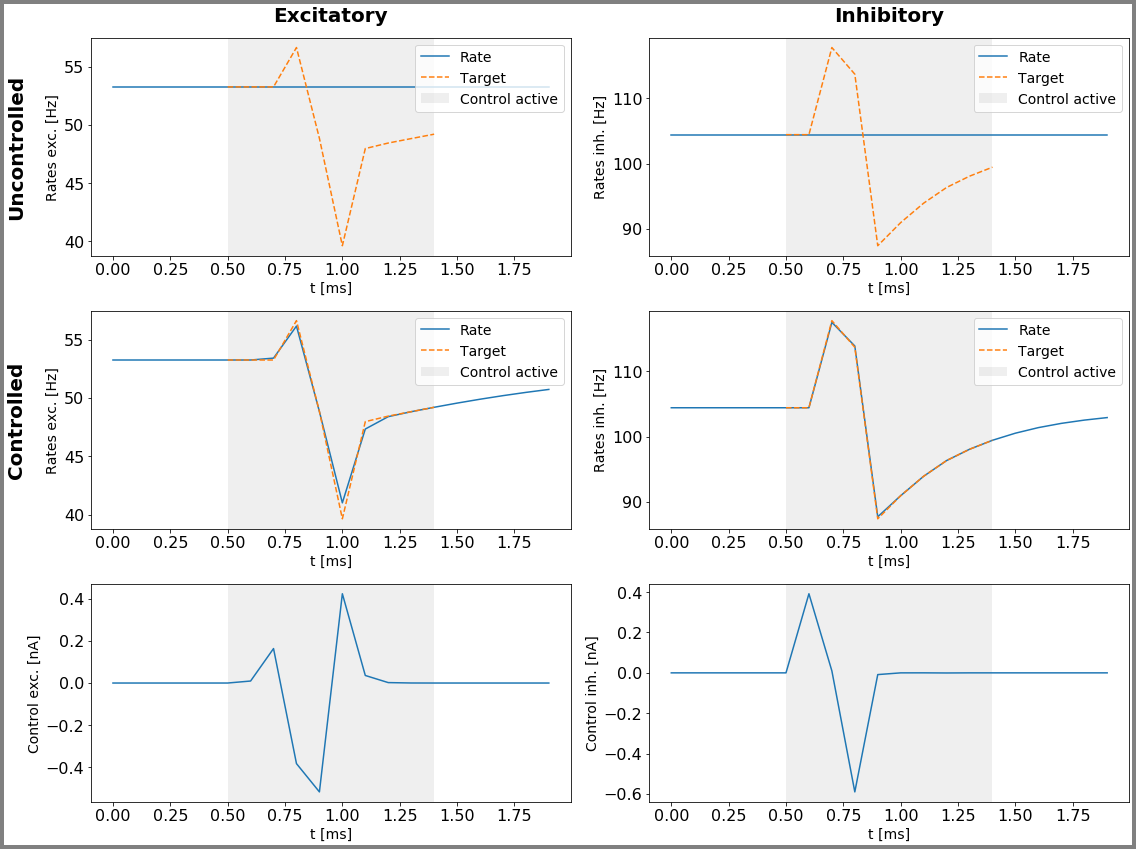

In [129]:
setinitvars(high_state_vars)
max_it = 800
alg = "A2"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()
control1 = bestControlA2[:,:,5:15]

bestControlA2, bestStateA2, costA2, runtimeA2 = aln.A2(control1, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))


for i in range(1, len(costA2)):
    if costA2[i-1] < costA2[i]:
        print("ERROR ---------------- in index ", i)

[[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00 -4.98891741e-03  1.32021648e-02
   -6.74752004e-03  1.66025420e-03 -7.47612462e-03  6.74893579e-03
   -6.62657510e-03  7.23999734e-03  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00 -6.47568119e-06 -1.49858883e-06
   -4.64930344e-06  3.60068455e-05 -3.87970233e-05 -1.70983869e-05
   -6.06053213e-06  3.37525537e-05  0.00000000e+00  0.00000000e+00
    0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]]]


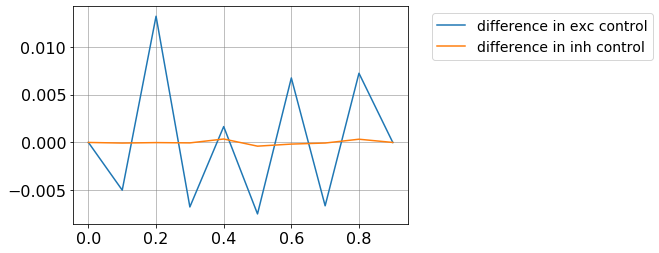

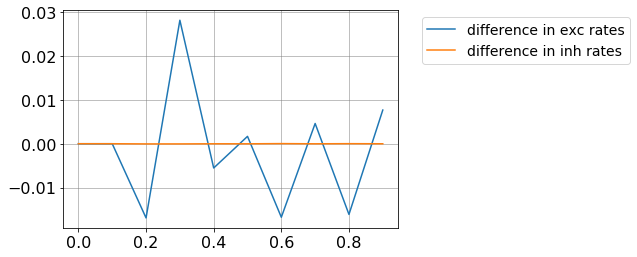

In [140]:
diff = bestControlA2 - bestControlA
diff_state = bestStateA2 - bestStateA

#diff[:,:,0] = 0
#diff[:,:,-1] = 0

sparsitygradientinh = np.array( [ 0.,9.49932197e-02,3.44809490e+00,-3.02161508e-02,-5.29884978e+00,
    -1.51166411e-01,-6.67096985e-03,-6.46825813e-05,-2.28743628e-04,0. ] )
adjointgradientinh = np.array( [ 0.,-9.49924781e-02,-3.44809399e+00,3.02175014e-02,5.29885118e+00,
     1.51167334e-01,6.67158491e-03,6.52247394e-05,2.28994155e-04,0. ] )

print(diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,5:15], label="difference in exc control")
plt.plot(t, 1e1 *diff[0,1,5:15], label="difference in inh control")
#plt.plot(t, bestControlA[0,1,5:15], label="inh control")
#plt.plot(t, - 1e1 * grad[0,0,:], label="grad exc")
#plt.plot(t, - 1e1 * grad[0,1,:], label="grad inh")
#plt.plot(t, - 1e0 *sparsitygradientinh, label = "sparsity grad")
#plt.plot(t, - 1e0 * adjointgradientinh, label = "adjoint grad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff_state[0,0,5:15], label="difference in exc rates")
plt.plot(t, diff_state[0,1,5:15], label="difference in inh rates")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

In [141]:
import sys
for path in sys.path:
    print(path)

D:\Promotion\neurolib\aln_control_20_11_12\test
D:\Promotion\neurolib
C:\Users\lenas\anaconda3\python37.zip
C:\Users\lenas\anaconda3\DLLs
C:\Users\lenas\anaconda3\lib
C:\Users\lenas\anaconda3

C:\Users\lenas\AppData\Roaming\Python\Python37\site-packages
C:\Users\lenas\anaconda3\lib\site-packages
C:\Users\lenas\anaconda3\lib\site-packages\win32
C:\Users\lenas\anaconda3\lib\site-packages\win32\lib
C:\Users\lenas\anaconda3\lib\site-packages\Pythonwin
C:\Users\lenas\anaconda3\lib\site-packages\IPython\extensions
C:\Users\lenas\.ipython
